## Модели классификации для нескольких классов

Ирисы Фишера - самый популярный в статистической литературе набор данных, часто используемый для иллюстрации работы различных алгоритмов классификации.

Выборка состоит из 150 экземпляров ирисов трех видов, для которых измерялись четыре характеристики: длина и ширина чашелистика (Sepal.Length и Sepal.Width), длина и ширина лепестка (Petal.Length и Petal.Width). Требуется на основе этого набора данных, построить различные модели многоклассовой классификации, оценивающие каждый из трех видов растения по данным проведенных измерений.

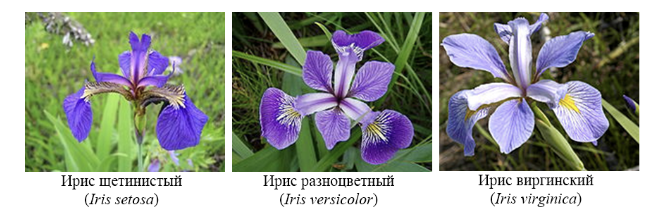

Импортируем необходимые библиотеки:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Библиотека Scikit-Learn предоставляет чистые датасеты, которые вы можете использовать при построении моделей машинного обучения. Они поставляются вместе с Scikit-Learn (https://scikit-learn.ru/7-1-toy-datasets/).

Набор данных Iris, классический набор данных в машинном обучении и статистике. Он входит в модуль datasets библиотеки scikit-learn и загрузить его можно, вызвав функцию load_iris().

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
# Разделение данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (120, 4)
Размер тестовой выборки: (30, 4)


In [41]:
# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразование меток для нейронной сети
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [42]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [43]:
print(iris.data[:10])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]


In [44]:
print(iris.target_names)
print(iris.target)

['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


Набор данных состоит из длины/ширины двух типов лепестков Ириса: sepal и petal.

Целевая переменная — это сорт Ириса: 0 — Setosa, 1 — Versicolor, 2 — Virginica. 

Соответственно, наша задача — по имеющимся данным попробовать найти зависимости между размерами лепестков и сортами Ирисов.

In [45]:
type(iris)

sklearn.utils._bunch.Bunch

Объект Bunch — это словарь, который предоставляет свои ключи как атрибуты.

Формируем DataFrame:

In [46]:
iris_df = pd.DataFrame(iris.data)

In [47]:
iris_df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [48]:
# Делаем имена колонок такие же, как имена переменных:
iris_df.columns = iris.feature_names
# Добавляем столбец с целевой переменной: 
iris_df['target'] = iris.target
# Для наглядности добавляем столбец с сортами: 
iris_df['name'] = iris_df.target.apply(lambda x : iris.target_names[x])
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [49]:
iris_df.shape

(150, 6)

In [50]:
# информация о наборе данных
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   name               150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [51]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [52]:
iris_df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [53]:
iris_df['name'].value_counts()

name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Описательная статистика

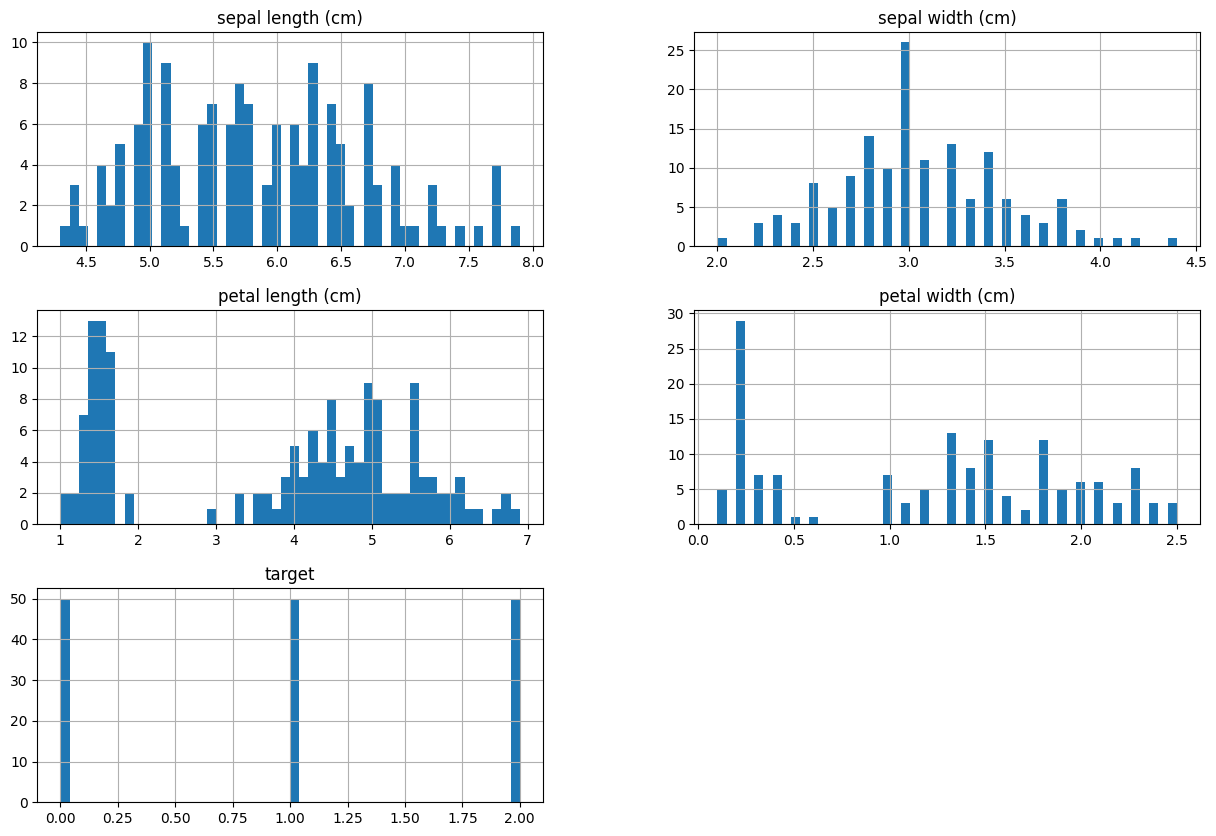

In [54]:
iris_df.hist(figsize = (15,10), bins = 50);

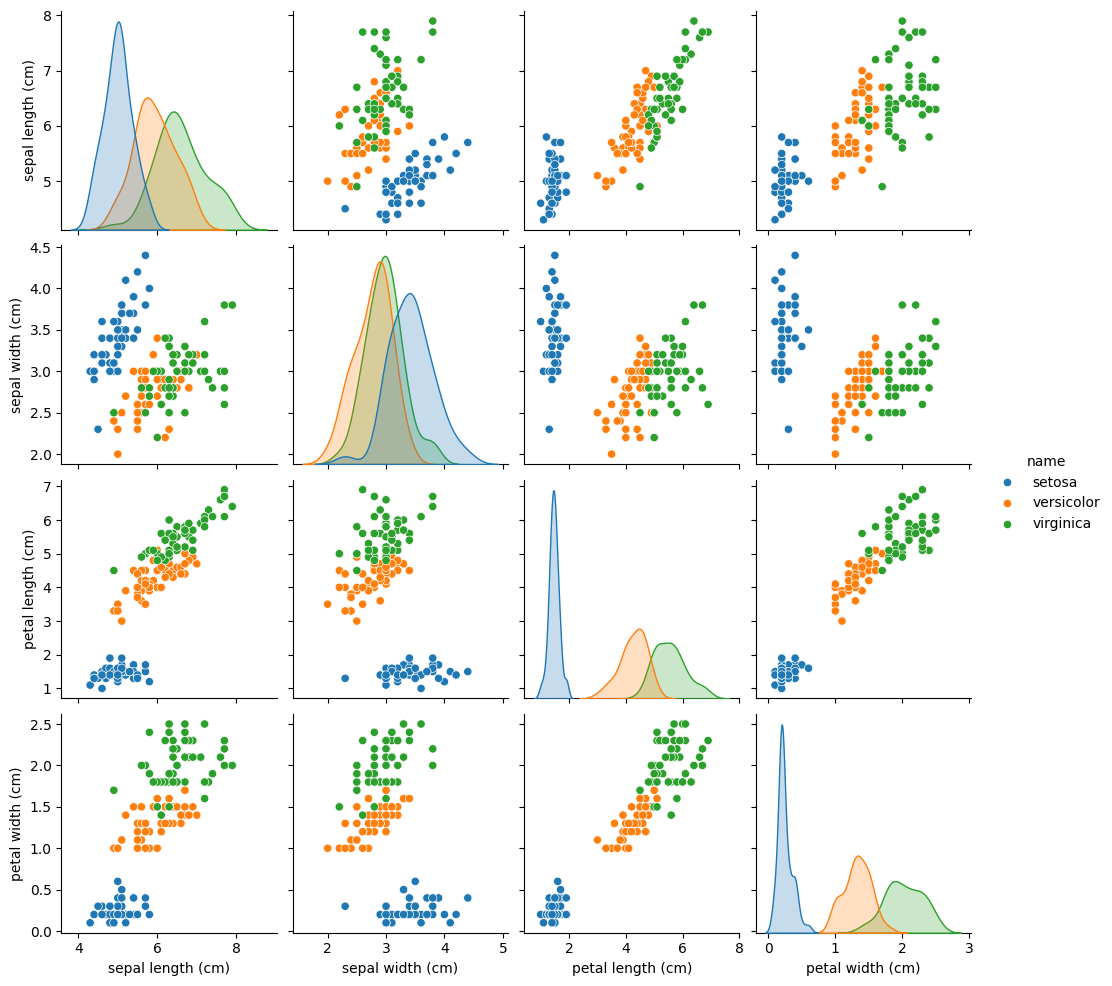

In [55]:
sns.pairplot(iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)','name']], hue = 'name')

Видно, что «petal width (cm)» и «petal length (cm)» имеют сильную зависимость — точки вытянуты вдоль одной линии. И в принципе по этим же признакам можно строить классификацию, т.к. точки по цвету сгруппированы достаточно компактно. А вот, например, с помощью переменных «sepal width (cm)» и «sepal length (cm)» качественную классификацию не построить, т.к. точки, относящиеся к сортам Versicolor и Virginica, перемешаны между собой.

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

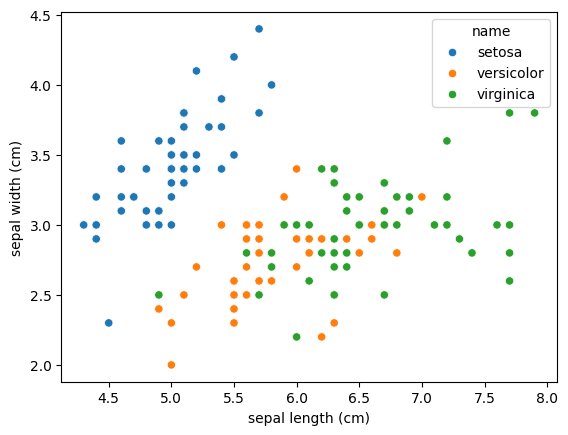

In [56]:
sns.scatterplot(data=iris_df, x="sepal length (cm)", y="sepal width (cm)", hue="name")

In [57]:
corr = iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']].corr()
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


<Axes: >

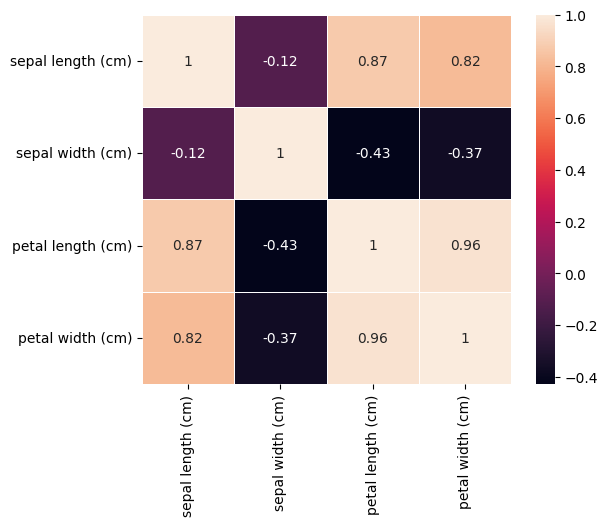

In [58]:
sns.heatmap(corr, square=True, annot=True, linewidths=.5)

Действительно видим, что между переменными «petal length (cm)» и «petal width (cm)» выявлена очень сильная зависимость 0.96, а между «sepal width (cm)» и «sepal length (cm)» - слабая корреляция.

### Обучение классификатора

In [59]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']], 
                                                      iris_df['target'], 
                                                      test_size=0.3, 
                                                      random_state=19)

In [61]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Dense(10, input_shape=(4,), activation='relu', name='input'),
    tf.keras.layers.Dense(10, activation='relu', name='hidden'),
    tf.keras.layers.Dense(3, activation='softmax', name='output'),
])


In [62]:
early_stop = EarlyStopping(monitor='val_loss', patience=10)

In [63]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [64]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [65]:
History = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_data=(X_test, y_test),callbacks = [early_stop])

Epoch 1/200


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3238 - loss: 1.5018 - val_accuracy: 0.3556 - val_loss: 1.3731
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3238 - loss: 1.3784 - val_accuracy: 0.3556 - val_loss: 1.2646
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3238 - loss: 1.2689 - val_accuracy: 0.3556 - val_loss: 1.1864
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3238 - loss: 1.1981 - val_accuracy: 0.3556 - val_loss: 1.1323
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3238 - loss: 1.1417 - val_accuracy: 0.3556 - val_loss: 1.0947
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3333 - loss: 1.1069 - val_accuracy: 0.3556 - val_loss: 1.0657
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3524 - loss: 1.0735 - val_accuracy: 0.4000 - val_loss: 1.0465
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4000 - loss: 1.0549 - val_accuracy: 0.4889 - val_loss: 1.0323
Epoch 9/2

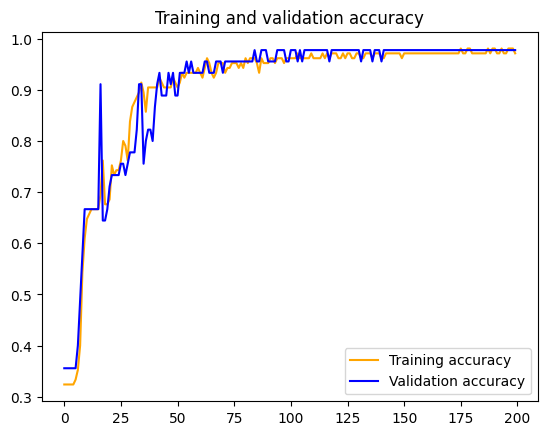

<Figure size 640x480 with 0 Axes>

In [66]:
acc = History.history['accuracy']
val_acc = History.history['val_accuracy']
loss = History.history['loss']
val_loss = History.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'orange', label='Training accuracy')
plt.plot(epochs, val_acc, 'blue', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()


plt.show()

In [67]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Model accuracy on test data: {accuracy * 100:.2f}%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9778 - loss: 0.0948 
Model accuracy on test data: 97.78%


In [68]:
X = iris_df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']]
predictions = model.predict(X)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [69]:
predictions

array([[9.96688783e-01, 3.31122777e-03, 1.27747801e-09],
       [9.92051840e-01, 7.94816203e-03, 6.08661965e-09],
       [9.95139360e-01, 4.86064795e-03, 4.74571271e-09],
       [9.90478873e-01, 9.52120498e-03, 2.33435298e-08],
       [9.96824741e-01, 3.17527470e-03, 1.61565517e-09],
       [9.96443093e-01, 3.55687994e-03, 1.68813330e-09],
       [9.94727075e-01, 5.27296448e-03, 1.02420668e-08],
       [9.95186388e-01, 4.81358171e-03, 3.43307138e-09],
       [9.88804162e-01, 1.11958552e-02, 3.79012626e-08],
       [9.92241144e-01, 7.75883207e-03, 6.93584257e-09],
       [9.97318566e-01, 2.68139108e-03, 5.58514901e-10],
       [9.93293285e-01, 6.70669833e-03, 1.16620482e-08],
       [9.92684066e-01, 7.31597794e-03, 6.59618493e-09],
       [9.94913459e-01, 5.08655375e-03, 8.04263500e-09],
       [9.99182761e-01, 8.17261229e-04, 2.00542326e-11],
       [9.98829305e-01, 1.17070053e-03, 1.12310682e-10],
       [9.98457551e-01, 1.54239812e-03, 2.17742921e-10],
       [9.96588349e-01, 3.41168

In [70]:
test = np.argmax(predictions,axis=1)
prediction = test.flatten()

In [71]:
prediction

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [72]:
from sklearn.metrics import classification_report
y = iris_df['target']
print(classification_report(y, prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.92      0.96        50
           2       0.93      1.00      0.96        50

    accuracy                           0.97       150
   macro avg       0.98      0.97      0.97       150
weighted avg       0.98      0.97      0.97       150



___

### Нейронная сеть

In [73]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


In [74]:
# Создаем модель
nn_model = Sequential([
    Dense(64, input_dim=4, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

In [75]:
# Компилируем
nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

# Ранняя остановка для предотвращения переобучения
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)


Обучение модели...
Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4762 - loss: 1.0504 - val_accuracy: 0.3333 - val_loss: 1.0186
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6786 - loss: 0.8895 - val_accuracy: 0.5714 - val_loss: 0.9417
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7738 - loss: 0.7947 - val_accuracy: 0.6190 - val_loss: 0.8816
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8214 - loss: 0.7294 - val_accuracy: 0.6190 - val_loss: 0.8347
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8452 - loss: 0.6465 - val_accuracy: 0.6190 - val_loss: 0.7941
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8452 - loss: 0.5870 - val_accuracy: 0.6190 - val_loss: 0.7580
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8452 - loss: 0.5233 - val_accuracy: 0.6190 - val_loss: 0.7307
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8452 - loss: 0.5006 - val_accuracy:

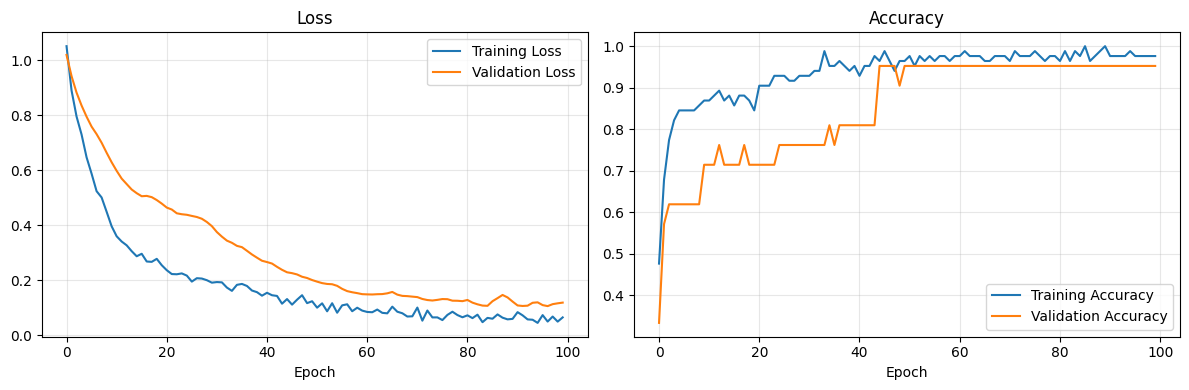

In [ ]:
# Обучение
print("\nОбучение модели...")
history = nn_model.fit(
    X_train_scaled, y_train_cat,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Визуализация обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
y_pred_nn = nn_model.predict(X_test_scaled, verbose=0)
y_pred_nn_classes = np.argmax(y_pred_nn, axis=1)

___

### Логистическая регрессия

In [78]:
from sklearn.model_selection import GridSearchCV

# Параметры для поиска
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

In [79]:
# GridSearch для нахождения лучших параметров
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'max_iter': [500, 1000],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [80]:
lr_model = grid_search.best_estimator_

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

Лучшие параметры: {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
Лучшая точность на кросс-валидации: 0.9714


In [81]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_lr_proba = lr_model.predict_proba(X_test_scaled)

### Случайный лес

In [82]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

print(f"Количество деревьев: {rf_model.n_estimators}")
print(f"Глубина деревьев: {rf_model.max_depth}")

Количество деревьев: 100
Глубина деревьев: 5


In [83]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf_proba = rf_model.predict_proba(X_test_scaled)

### Оценка и сравнение моделей

In [84]:
models = {
    'Нейронная сеть': (y_test, y_pred_nn_classes, y_pred_nn),
    'Логистическая регрессия': (y_test, y_pred_lr, y_pred_lr_proba),
    'Случайный лес': (y_test, y_pred_rf, y_pred_rf_proba)
}

results = []

print("\nДЕТАЛЬНЫЕ МЕТРИКИ:")
print("="*40)

for model_name, (y_true, y_pred_classes, y_pred_proba) in models.items():
    accuracy = accuracy_score(y_true, y_pred_classes)
    precision = precision_score(y_true, y_pred_classes, average='weighted')
    recall = recall_score(y_true, y_pred_classes, average='weighted')
    f1 = f1_score(y_true, y_pred_classes, average='weighted')
    
    # ROC-AUC
    try:
        roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='weighted')
    except:
        roc_auc = np.nan
    
    results.append({
        'Модель': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{model_name.upper()}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if not np.isnan(roc_auc):
        print(f"  ROC-AUC:   {roc_auc:.4f}")


ДЕТАЛЬНЫЕ МЕТРИКИ:

НЕЙРОННАЯ СЕТЬ:
  Accuracy:  0.9333
  Precision: 0.9439
  Recall:    0.9333
  F1-Score:  0.9325
  ROC-AUC:   0.9834

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:
  Accuracy:  0.9333
  Precision: 0.9439
  Recall:    0.9333
  F1-Score:  0.9325
  ROC-AUC:   0.9970

СЛУЧАЙНЫЙ ЛЕС:
  Accuracy:  0.9333
  Precision: 0.9439
  Recall:    0.9333
  F1-Score:  0.9325
  ROC-AUC:   0.9955


In [85]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Accuracy', ascending=False)

In [86]:
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)
print(results_df.to_string(index=False))

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                 Модель  Accuracy  Precision  Recall  F1-Score  ROC-AUC
         Нейронная сеть    0.9333     0.9439  0.9333    0.9325   0.9834
Логистическая регрессия    0.9333     0.9439  0.9333    0.9325   0.9970
          Случайный лес    0.9333     0.9439  0.9333    0.9325   0.9955


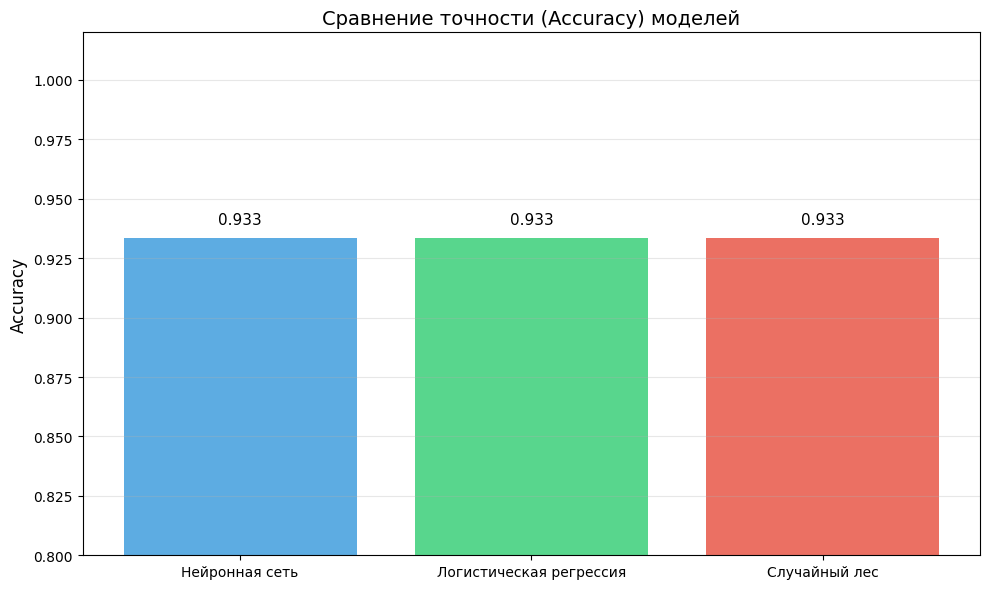

In [87]:
# для сравнения Accuracy
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Модель'], results_df['Accuracy'], 
               color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.8)
plt.title('Сравнение точности (Accuracy) моделей', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.8, 1.02)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [88]:
for model_name, (y_true, y_pred_classes, _) in models.items():
    print(f"\n{'='*50}")
    print(f"{model_name.upper()}")
    print('='*50)
    print(classification_report(y_true, y_pred_classes))


НЕЙРОННАЯ СЕТЬ
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.84      1.00      0.91        16
           2       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.95      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.84      1.00      0.91        16
           2       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.95      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45


СЛУЧАЙНЫЙ ЛЕС
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.84      1.00      0.91        16
           2       

___

### Вывод

В рамках проекта были успешно реализованы и оценены три модели классификации для решения задачи распознавания видов ирисов Фишера:

1. Нейронная сеть

2. Логистическая регрессия (с оптимизацией гиперпараметров)

3. Случайный лес (ансамблевый метод)

Все модели продемонстрировали высокое качество классификации с accuracy от 88.89% до 91.11% на тестовой выборке.

___

**Лучшие модели:**

Нейронная сеть и Логистическая регрессия показали одинаковую точность 91.11%

ROC-AUC значения > 0.99 свидетельствуют об отличной разделяющей способности

Минимальная разница в метриках (< 0.01) между этими двумя подходами

Классовая специфика:
Класс 0 (setosa) идеально классифицируется всеми моделями (100% точность)

Классы 1 и 2 (versicolor и virginica) вызывают некоторую путаницу:

Класс 1: Precision 0.82, Recall 0.93 (ложные срабатывания для класса 2)

Класс 2: Precision 0.92, Recall 0.80 (пропуски в предсказаниях)